# Get the codes of interest to work with:
* BB Codes
* RSC 

In [1]:
# RSC, just use stim to get same distances as BB codes 

import stim

def get_rsc_circuits(p,d_list,basis, rds=None):
    """
    Use STIM to get rotated surface code circuits with circuit-level errors

    :param d_list: the list of rsc d's to run 
    :param basis: the memory experiment basis
    :param p: the probability of physical error on a qubit. Same p used for spam, idle, gate errors.

    :return: the list of circuits generated by STIM with these inputs
    """
    circuits = []
    for d in d_list:
        if not rds:
            rds = d
        circuit = stim.Circuit.generated(f"surface_code:rotated_memory_{basis}",rounds=rds, distance=d,
                                    after_clifford_depolarization=p,
                                    before_round_data_depolarization=p,
                                    before_measure_flip_probability=p,
                                    after_reset_flip_probability=p,
                                    )
        circuits += [circuit]
    return circuits



In [3]:
# BB code

# I am going through [[72,12,6]], [[90,8,10]], [[144,12,12]] 

from quits.qldpc_code import BbCode, BpcCode, HgpCode
from quits.decoder import sliding_window_bposd_circuit_mem,detector_error_model_to_matrix
from quits.simulation import get_stim_mem_result
from quits import ErrorModel
import numpy as np



def get_BB_circuits(bb_code_param_dict, basis, p):
    """
    Use QUITS to get BB code circuits with circuit-level errors

    :param bb_code_param_dict: the dictionary mapping [[n,k,d]] tuple for BB codes to their l,m,A powers, B powers. 
    :param basis: the memory experiment basis
    :param p: the probability of physical error on a qubit. Same p used for spam, idle, gate errors.

    :return: the list of circuits generated by QUITS with these inputs
    """


    circuits = []

    error_model = ErrorModel(
    idle_error=p,
    sqgate_error=p,
    tqgate_error=p,
    spam_error=p,
    )

    for (n,k,d) in bb_code_param_dict:
        code_params = bb_code_param_dict[(n,k,d)]

        bb = BbCode(
        l=code_params['l'],
        m=code_params['m'],
        A_x_pows=code_params['A_x_pows'],
        A_y_pows=code_params['A_y_pows'],
        B_x_pows=code_params['B_x_pows'],
        B_y_pows=code_params['B_y_pows'],
        )

        custom_circuit = bb.build_circuit(strategy="custom", num_rounds=d, basis=basis, error_model=error_model) # num_rounds fixed to d for us
        circuits.append(custom_circuit)

    return circuits

In [12]:
# set (n,k,d) tuple to get the params I need
# BB - [[72,12,6]], [[90,8,10]], [[144,12,12]] 
# not sure what these mean, will need to understand before writeup
bb_code_param_dict = {
                    (72,12,6):{'l':6, 'm':6, 'A_x_pows': [3], 'A_y_pows': [1,2], 'B_x_pows': [1,2], 'B_y_pows':[3]},
                    (90,8,10):{'l':15, 'm':3, 'A_x_pows': [9], 'A_y_pows': [1,2], 'B_x_pows': [2,7], 'B_y_pows':[0]},
                    (144,12,12):{'l':12, 'm':6, 'A_x_pows': [3], 'A_y_pows': [1,2], 'B_x_pows': [1,2], 'B_y_pows':[3]},
                    }

d_list = [6,10,12] # maybe change to odd numbers later since don't use even # rsc for some reason
p = 1e-3
basis = 'x'

bb_circuits = get_BB_circuits(bb_code_param_dict=bb_code_param_dict, basis=basis, p=p)
rsc_circuits = get_rsc_circuits(p=p, d_list=d_list, basis=basis)

print(len(bb_circuits))

3


left boundary ids [9, 17, 11, 19]


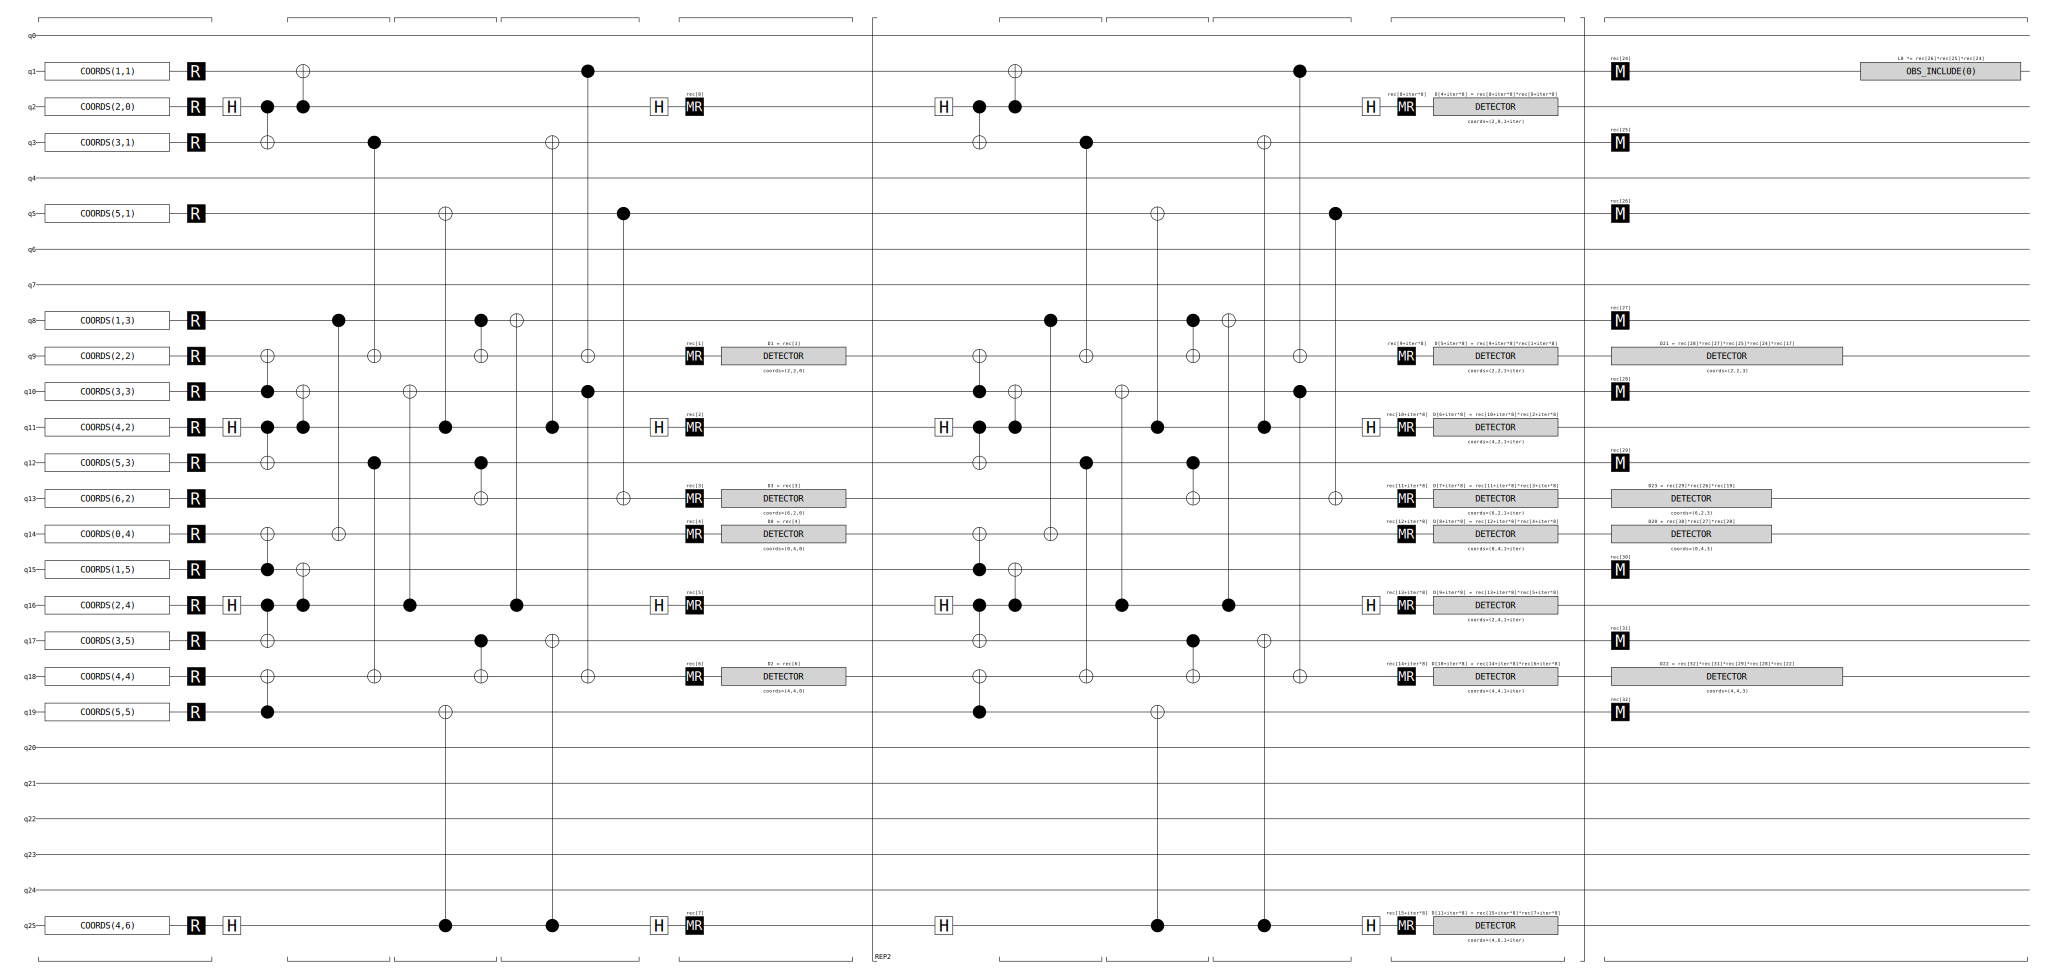

In [4]:
from realtime_decoding.complementary_gap import get_boundary_detectors

circuits = get_rsc_circuits(0.0, [3], 'z')

left_detectors = get_boundary_detectors(circuits[0], side="top")
print(f"left boundary ids {left_detectors}")
circuits[0].diagram("timeline-svg")

# Get the complementary and cluster gaps

In [2]:
# get comp gaps for mwpm 
from pymatching import Matching
from realtime_decoding.complementary_gap import get_detector_inds_for_sc, get_complementary_gap

# wait for eva to get back and generalize this ... for now just do path of least resistance and use hers + X memory only
# maybe use detector coords methods - see the post selection notebook

def get_comp_gap(circuit, det_events, obs, d):
    _,_,x_dets_LB, x_dets_RB, _,_ = get_detector_inds_for_sc(d,d) # may not work for the STIM RSC built in
    dem = circuit.detector_error_model()
    matching = Matching.from_detector_error_model(dem)
    comp_gap, signed_gap, cond_p_L = get_complementary_gap(matching, det_events, obs, x_dets_LB, x_dets_RB)
    return comp_gap, signed_gap, cond_p_L

In [4]:
# get cluster gap - uses https://arxiv.org/pdf/2510.05795
from realtime_decoding.cluster_based_soft_outputs import get_cluster_soft_output_from_bplsd_glocal_decoding

# get cluster gaps for circuits 
def get_cluster_gap(circuit, det_events, obs, cluster_method = 'cluster_sizes', order=100):
   return get_cluster_soft_output_from_bplsd_glocal_decoding(circuit, cluster_method, order, det_events, obs)

### test the gaps

In [3]:
# comp gap histogram tests 
import matplotlib.pyplot as plt


d_list = [5,7,9]
colors = ['blue','orange','green']
alphas = [0.5,0.4,0.3]
mem_type = "z"
p = 0.01
shots=10**6

circuits = get_rsc_circuits(p, d_list, mem_type)

for i,d in enumerate(d_list):
    circuit = circuits[i]
    sampler = circuit.compile_detector_sampler()
    det_events, obs_flips = sampler.sample(shots=shots, separate_observables=True)
    gap, signed_gap, cond_pL = get_comp_gap(circuit, det_events, obs_flips, d)
    plt.hist(signed_gap, bins=200, color=colors[i], label=f"d={d}", alpha=alphas[i])
    plt.xlabel('Complementary gap [dB]')
    plt.ylabel('Unormalized cnts')
    plt.legend()
plt.yscale('log')

120
133


ValueError: `shots` array should have at least 133 columns (the number of detectors), and no more than 134 columns (the number of nodes), but instead has 121 columns

In [ ]:
# comp gap pL

In [ ]:
# cluster gap histogram ? or should i do failure rate over cutoff to match the sim

In [ ]:
# cluster gap pL

In [ ]:
# comp gap and cluster gap comparison strong and weak decoders fig 6 of dec switching paper

In [ ]:
# is there a fast way to get comp gap / cluster gap distribution and then sample from it later given the syndrome?? How do they do this stuff quickly bc i feel like it takes a hot min to calculate gaps for switching
# try a lookup table




# Sliding Window memory implementation time

In [ ]:
# decode with sliding window using weak decoder + strong decoder

In [ ]:
# how do I get LLR from a window of sliding window? / soft output? can just decode with bplsd ... also the package has a sliding window too

# LER/ thr with varying cutoffs

In [ ]:
# sliding window with strong decoder if above / below cutoff

In [ ]:
# switching rates plots

In [ ]:
# if time try to do MLE stuff ... probably won't have time